### Prof. Pedram Jahangiry

You need to make a copy to your own Google drive if you want to edit the original notebook! Start by opening this notebook on Colab 👇

<a href="https://colab.research.google.com/github/PJalgotrader/Deep_Learning-USU/blob/main/Lectures%20and%20codes/Module%203-%20Machine%20Learning%20Review/Module%203-%20ML%20PyCaret-Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



![logo](https://upload.wikimedia.org/wikipedia/commons/4/44/Huntsman-Wordmark-with-USU-Blue.gif#center)


## 🔗 Links

[![linkedin](https://img.shields.io/badge/LinkedIn-0A66C2?style=for-the-badge&logo=linkedin&logoColor=white)](https://www.linkedin.com/in/pedram-jahangiry-cfa-5778015a)

[![Youtube](https://img.shields.io/badge/youtube_channel-1DA1F2?style=for-the-badge&logo=youtube&logoColor=white&color=FF0000)](https://www.youtube.com/channel/UCNDElcuuyX-2pSatVBDpJJQ)

[![Twitter URL](https://img.shields.io/twitter/url/https/twitter.com/PedramJahangiry.svg?style=social&label=Follow%20%40PedramJahangiry)](https://twitter.com/PedramJahangiry)


---


# ⚠️ Important: How to install PyCaret (read this first)

**We are using PyCaret 3.5.0, installed from the `pycaret-core` package.** The older `pycaret==3.3.2` release only supports Python 3.9 to 3.11 and is no longer updated, so `pip install pycaret` does not work on Google Colab or on any current Python. `pycaret-core` is the maintained continuation of PyCaret 3: same `import pycaret`, same functions, and it runs on Python 3.13.

### On Google Colab
Run the install cell below **first, in a fresh runtime**, before importing PyCaret. It detects Colab and runs:
```
pip install pycaret-core xgboost lightgbm catboost
```
This installs the PyCaret core library plus the three boosting libraries we use in this notebook. An alternative is `pip install pycaret-core[full]`, which pulls in every optional dependency, but it is heavier and slower to install.

No runtime restart is needed after the install. PyCaret checks which optional libraries exist the first time it is imported, so anything you install *after* importing it stays invisible (`Estimator ... Not Available`). If that happens, use Runtime ▸ Disconnect and delete runtime, then run the notebook from the top.

After the install finishes, verify with the version cell below (you should see **3.5.0**).

### On your own machine (conda)
The install cell does nothing outside Colab. Instead, create the course's PyCaret environment once, from the root of your cloned copy of this repo:
```
conda env create -f environment.yml
conda activate dl_pycaret
python scripts/check_environment.py
```
[`environment.yml`](https://github.com/PJalgotrader/Deep_Learning-USU/blob/main/environment.yml) uses **Python 3.13** (the same as Colab) and covers every PyCaret notebook in this course. The check script should end with "Your course environment is ready." Then open this notebook in JupyterLab or VS Code and pick the `dl_pycaret` environment as the kernel. Details and troubleshooting are in the [PyCaret setup guide](https://github.com/PJalgotrader/Deep_Learning-USU/blob/main/Platforms%20and%20tools/PyCaret/README.md). For a walkthrough of PyCaret itself, see my PyCaret playlist: https://www.youtube.com/playlist?list=PL2GWo47BFyUOqCAj_16yeNspfeM0nfA6q


# Module3- ML with PyCaret

## Installation

Follow the instructions at the top of this notebook: on Google Colab run the next cell; on your own machine use the `dl_pycaret` conda environment, where the next cell does nothing.

In [1]:
# Google Colab only: installs PyCaret 3.5.0 (pycaret-core) plus the libraries this notebook needs.
# On your own machine this cell does nothing (use the dl_pycaret conda environment, see the note above).
# Run it FIRST in a fresh runtime, before importing pycaret.
import sys
if "google.colab" in sys.modules:
    !pip install -q pycaret-core xgboost lightgbm catboost

In [2]:
# let's double ckeck the Pycaret version:
from pycaret.utils import version
version()

'3.5.0'

## Importing Dataset

In [3]:
from pycaret.datasets import get_data
# try get_data('index') to see the list of all available data.

In [4]:
get_data('index')

,Dataset,Data Types,Default Task,Target Variable 1,Target Variable 2,# Instances,# Attributes,Missing Values
0,anomaly,Multivariate,Anomaly Detection,NaN,NaN,1000,10,N
1,france,Multivariate,Association Rule Mining,InvoiceNo,Description,8557,8,N
2,germany,Multivariate,Association Rule Mining,InvoiceNo,Description,9495,8,N
3,bank,Multivariate,Classification (Binary),deposit,NaN,45211,17,N
4,blood,Multivariate,Classification (Binary),Class,NaN,748,5,N
5,cancer,Multivariate,Classification (Binary),Class,NaN,683,10,N
6,credit,Multivariate,Classification (Binary),default,NaN,24000,24,N
7,diabetes,Multivariate,Classification (Binary),Class variable,NaN,768,9,N
8,electrical_grid,Multivariate,Classification (Binary),stabf,NaN,10000,14,N
9,employee,Multivariate,Classification (Binary),left,NaN,14999,10,N


,Dataset,Data Types,Default Task,Target Variable 1,Target Variable 2,# Instances,# Attributes,Missing Values
0,anomaly,Multivariate,Anomaly Detection,NaN,NaN,1000,10,N
1,france,Multivariate,Association Rule Mining,InvoiceNo,Description,8557,8,N
2,germany,Multivariate,Association Rule Mining,InvoiceNo,Description,9495,8,N
3,bank,Multivariate,Classification (Binary),deposit,NaN,45211,17,N
4,blood,Multivariate,Classification (Binary),Class,NaN,748,5,N
5,cancer,Multivariate,Classification (Binary),Class,NaN,683,10,N
6,credit,Multivariate,Classification (Binary),default,NaN,24000,24,N
7,diabetes,Multivariate,Classification (Binary),Class variable,NaN,768,9,N
8,electrical_grid,Multivariate,Classification (Binary),stabf,NaN,10000,14,N
9,employee,Multivariate,Classification (Binary),left,NaN,14999,10,N


In [5]:
dataset = get_data('employee')

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,department,salary,left
0,0.38,0.53,2,157,3,0,0,sales,low,1
1,0.80,0.86,5,262,6,0,0,sales,medium,1
2,0.11,0.88,7,272,4,0,0,sales,medium,1
3,0.72,0.87,5,223,5,0,0,sales,low,1
4,0.37,0.52,2,159,3,0,0,sales,low,1


In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   promotion_last_5years  14999 non-null  int64  
 7   department             14999 non-null  object 
 8   salary                 14999 non-null  object 
 9   left                   14999 non-null  int64  
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [7]:
dataset.nunique()

satisfaction_level        92
last_evaluation           65
number_project             6
average_montly_hours     215
time_spend_company         8
Work_accident              2
promotion_last_5years      2
department                10
salary                     3
left                       2
dtype: int64

In [8]:
dataset.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident',
       'promotion_last_5years', 'department', 'salary', 'left'],
      dtype='object')

In [9]:

categoricals = ['Work_accident','promotion_last_5years', 'department', 'salary']

In [10]:
# for the sake of time, let's work wity a tiny subsample of data
dataset = dataset.sample(5000)

In [11]:
data = dataset.sample(frac=0.9, random_state=123)
data_unseen = dataset.drop(data.index)

data.reset_index(drop=True, inplace=True)
data_unseen.reset_index(drop=True, inplace=True)

print('Data for Modeling: ' + str(data.shape))
print('Unseen Data For Predictions: ' + str(data_unseen.shape))

Data for Modeling: (4500, 10)
Unseen Data For Predictions: (500, 10)


In [12]:
data.shape

(4500, 10)

In [13]:
data.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,department,salary,left
0,0.57,0.46,3,167,4,0,0,technical,medium,0
1,0.90,0.78,3,162,2,0,0,sales,medium,0
2,0.53,0.57,5,141,3,1,0,technical,high,0
3,0.11,0.80,7,243,4,0,0,sales,medium,1
4,0.88,0.71,5,255,3,0,0,support,medium,0


In [14]:
data.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident',
       'promotion_last_5years', 'department', 'salary', 'left'],
      dtype='object')

## Setting up Environment in PyCaret

**setup()**:

This function initializes the training environment and creates the transformation pipeline. Setup function must be called before executing any other function. It takes two mandatory parameters: data and target. All the other parameters are optional.

In [15]:
from pycaret.classification import *

The latest version of PyCaret is Object oriented API. This means that the settings are linked with an object, you can run as many experiments as you want in the same notebook and compare them seamlessly not just across different modeling options but also different preprocessing settings.


### ⚠️ A note on `data_split_shuffle=False`

On Python 3.13 with pandas ≥ 2.2 (both Google Colab and the `dl_pycaret` conda environment) PyCaret 3.5.0 has a preprocessing bug: when it merges transformed columns back into the dataset, pandas now **sorts the rows by index**, but the target column keeps its old order. Rows of `X` and `y` end up mismatched, every model degrades to the majority-class accuracy (~77%), and recall drops to 0.

Our `data` is already shuffled (we built it with `.sample()` and reset the index), so we do not need PyCaret to shuffle it again. Setting `data_split_shuffle=False` keeps the row index in increasing order, the sort becomes a no-op, and everything stays aligned. `data_split_stratify=False` is required alongside it (scikit-learn cannot stratify an unshuffled split). Do **not** set `fold_shuffle=True` on this stack for the same reason.


In [16]:
exp = ClassificationExperiment()
exp.setup(data, target='left', session_id=555, categorical_features=categoricals, train_size=0.8, preprocess=True,
          data_split_shuffle=False, data_split_stratify=False)   # see the note above (Colab / pandas >= 2.2)


,Description,Value
0,Session id,555
1,Target,left
2,Target type,Binary
3,Original data shape,"(4500, 10)"
4,Transformed data shape,"(4500, 21)"
5,Transformed train set shape,"(3600, 21)"
6,Transformed test set shape,"(900, 21)"
7,Numeric features,5
8,Categorical features,4
9,Preprocess,True


In [17]:
# list of available models in PyCaret for classification.
exp.models()

,Name,Reference,Turbo
ID,,,
lr,Logistic Regression,sklearn.linear_model._logistic.LogisticRegression,True
knn,K Neighbors Classifier,sklearn.neighbors._classification.KNeighborsCl...,True
nb,Naive Bayes,sklearn.naive_bayes.GaussianNB,True
dt,Decision Tree Classifier,sklearn.tree._classes.DecisionTreeClassifier,True
svm,SVM - Linear Kernel,sklearn.linear_model._stochastic_gradient.SGDC...,True
rbfsvm,SVM - Radial Kernel,sklearn.svm._classes.SVC,False
gpc,Gaussian Process Classifier,sklearn.gaussian_process._gpc.GaussianProcessC...,False
mlp,MLP Classifier,sklearn.neural_network._multilayer_perceptron....,False
ridge,Ridge Classifier,sklearn.linear_model._ridge.RidgeClassifier,True


## Compare Models

This function trains and evaluates performance of all estimators available in the model library using cross validation. The output of this function is a score grid with average cross validated scores. Metrics evaluated during CV can be accessed using the get_metrics function. Custom metrics can be added or removed using add_metric and remove_metric function.

In [18]:
exp.compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.9764,0.9811,0.9328,0.9679,0.9498,0.9344,0.9348,0.1090
rf,Random Forest Classifier,0.9744,0.9814,0.9120,0.9803,0.9445,0.9280,0.9293,0.0270
catboost,CatBoost Classifier,0.9744,0.9841,0.9212,0.9709,0.9453,0.9286,0.9293,0.2460
xgboost,Extreme Gradient Boosting,0.9742,0.9803,0.9270,0.9640,0.9450,0.9281,0.9286,0.0510
gbc,Gradient Boosting Classifier,0.9725,0.9838,0.9178,0.9662,0.9412,0.9233,0.9239,0.0290
et,Extra Trees Classifier,0.9711,0.9779,0.9073,0.9707,0.9375,0.9188,0.9200,0.0250
dt,Decision Tree Classifier,0.9561,0.9465,0.9282,0.8931,0.9103,0.8812,0.8816,0.1710
ada,Ada Boost Classifier,0.9264,0.9606,0.8099,0.8751,0.8400,0.7923,0.7943,0.0150
knn,K Neighbors Classifier,0.9189,0.9513,0.8957,0.7936,0.8414,0.7872,0.7899,0.2140
qda,Quadratic Discriminant Analysis,0.8392,0.8920,0.8019,0.6335,0.7058,0.5978,0.6073,0.0080


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [19]:
# Adding the list of models we want to include in our study:
model_list = ['lr', 'dt', 'rf', 'xgboost', 'catboost', 'lightgbm']

In [20]:
my_models = exp.compare_models(include=model_list, n_select=6)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.9764,0.9811,0.9328,0.9679,0.9498,0.9344,0.9348,0.1240
rf,Random Forest Classifier,0.9744,0.9814,0.9120,0.9803,0.9445,0.9280,0.9293,0.0250
catboost,CatBoost Classifier,0.9744,0.9841,0.9212,0.9709,0.9453,0.9286,0.9293,0.2320
xgboost,Extreme Gradient Boosting,0.9742,0.9803,0.9270,0.9640,0.9450,0.9281,0.9286,0.0330
dt,Decision Tree Classifier,0.9561,0.9465,0.9282,0.8931,0.9103,0.8812,0.8816,0.0080
lr,Logistic Regression,0.7789,0.8039,0.2990,0.5843,0.3932,0.2746,0.2991,0.0130


## Tune model

This function tunes the hyperparameters of a given estimator. The output of this function is a score grid with CV scores by fold of the best selected model based on optimize parameter. Metrics evaluated during CV can be accessed using the get_metrics function. Custom metrics can be added or removed using add_metric and remove_metric function.

In [21]:
data['left'].value_counts()
# data is relatively balanced, we can optimize based on accuracy.

left
0    3402
1    1098
Name: count, dtype: int64

In [22]:
my_models

[LGBMClassifier(boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
                importance_type='split', learning_rate=0.1, max_depth=-1,
                min_child_samples=20, min_child_weight=0.001, min_split_gain=0.0,
                n_estimators=100, n_jobs=-1, num_leaves=31, objective=None,
                random_state=555, reg_alpha=0.0, reg_lambda=0.0, subsample=1.0,
                subsample_for_bin=200000, subsample_freq=0),
 RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                        criterion='gini', max_depth=None, max_features='sqrt',
                        max_leaf_nodes=None, max_samples=None,
                        min_impurity_decrease=0.0, min_samples_leaf=1,
                        min_samples_split=2, min_weight_fraction_leaf=0.0,
                        monotonic_cst=None, n_estimators=100, n_jobs=-1,
                        oob_score=False, random_state=555, verbose=0,
                        warm_start=False),


### ⚠️ A note on tuning CatBoost (Google Colab)

PyCaret's default hyperparameter grid for CatBoost samples `n_estimators` from a NumPy range, so the candidate values are **NumPy integers**. Recent CatBoost versions (1.2.6 and newer, which is what Colab installs) convert those to plain Python integers inside the constructor. Scikit-learn's `clone()` then complains that the "constructor modifies parameter n_estimators" and **every fit in the random search fails**.

The fix is simple: pass `tune_model()` a **custom grid made of plain Python numbers**. The grid below is only used for CatBoost; the other models keep PyCaret's default grid. Same idea for the `tuned_catboost` cell further down.


In [23]:
# Custom grid for CatBoost (plain Python numbers only, see the note above)
catboost_grid = {
    'depth':        [4, 6, 8, 10],
    'eta':          [0.01, 0.05, 0.1, 0.3],   # learning rate
    'n_estimators': [100, 200, 300, 500],
    'l2_leaf_reg':  [1, 3, 5, 10],
}


In [24]:
# Tune every model. CatBoost gets the custom grid; everything else uses PyCaret's default grid.
tuned_models = [
    exp.tune_model(model, optimize='Accuracy',
                   custom_grid=catboost_grid if 'CatBoost' in type(model).__name__ else None)
    for model in my_models
]


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9722,0.9782,0.9186,0.9634,0.9405,0.9224,0.9228
1,0.9750,0.9822,0.9419,0.9529,0.9474,0.9310,0.9310
2,0.9833,0.9672,0.9302,1.0000,0.9639,0.9530,0.9541
3,0.9750,0.9762,0.9186,0.9753,0.9461,0.9299,0.9306
4,0.9833,0.9739,0.9419,0.9878,0.9643,0.9534,0.9539
5,0.9806,0.9755,0.9186,1.0000,0.9576,0.9450,0.9464
6,0.9861,0.9966,0.9651,0.9765,0.9708,0.9617,0.9617
7,0.9556,0.9824,0.8621,0.9494,0.9036,0.8748,0.8765
8,0.9778,0.9802,0.9425,0.9647,0.9535,0.9389,0.9390


Fitting 10 folds for each of 10 candidates, totalling 100 fits


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9667,0.9669,0.8953,0.9625,0.9277,0.9061,0.9071
1,0.9583,0.9766,0.9070,0.9176,0.9123,0.8850,0.8850
2,0.9722,0.9763,0.9070,0.9750,0.9398,0.9217,0.9228
3,0.9778,0.9857,0.9302,0.9756,0.9524,0.9379,0.9384
4,0.9667,0.9754,0.9070,0.9512,0.9286,0.9068,0.9073
5,0.9583,0.9820,0.8837,0.9383,0.9102,0.8831,0.8838
6,0.9833,0.9950,0.9535,0.9762,0.9647,0.9538,0.9539
7,0.9611,0.9795,0.8736,0.9620,0.9157,0.8905,0.8922
8,0.9667,0.9772,0.8966,0.9630,0.9286,0.9069,0.9079


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9750,0.9767,0.9070,0.9873,0.9455,0.9293,0.9307
1,0.9750,0.9890,0.9419,0.9529,0.9474,0.9310,0.9310
2,0.9778,0.9632,0.9302,0.9756,0.9524,0.9379,0.9384
3,0.9806,0.9683,0.9302,0.9877,0.9581,0.9454,0.9462
4,0.9778,0.9674,0.9419,0.9643,0.9529,0.9384,0.9385
5,0.9778,0.9749,0.9186,0.9875,0.9518,0.9374,0.9384
6,0.9917,0.9955,0.9767,0.9882,0.9825,0.9770,0.9770
7,0.9639,0.9828,0.8736,0.9744,0.9212,0.8979,0.9001
8,0.9778,0.9801,0.9425,0.9647,0.9535,0.9389,0.9390


Fitting 10 folds for each of 10 candidates, totalling 100 fits


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9667,0.9733,0.9186,0.9405,0.9294,0.9076,0.9077
1,0.9639,0.9797,0.9302,0.9195,0.9249,0.9011,0.9011
2,0.9722,0.9697,0.9302,0.9524,0.9412,0.9230,0.9231
3,0.9722,0.9680,0.9419,0.9419,0.9419,0.9236,0.9236
4,0.9806,0.9752,0.9535,0.9647,0.9591,0.9463,0.9463
5,0.9556,0.9766,0.9186,0.8977,0.9080,0.8787,0.8788
6,0.9861,0.9950,0.9767,0.9655,0.9711,0.9620,0.9620
7,0.9611,0.9803,0.8966,0.9398,0.9176,0.8922,0.8926
8,0.9750,0.9749,0.9425,0.9535,0.9480,0.9315,0.9316


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9611,0.9622,0.8953,0.9390,0.9167,0.8913,0.8918
1,0.9583,0.9627,0.9070,0.9176,0.9123,0.8850,0.8850
2,0.9722,0.9571,0.8953,0.9872,0.9390,0.9211,0.9229
3,0.9556,0.9500,0.8953,0.9167,0.9059,0.8768,0.8769
4,0.9639,0.9576,0.8953,0.9506,0.9222,0.8987,0.8994
5,0.9528,0.9642,0.8605,0.9367,0.8970,0.8664,0.8677
6,0.9667,0.9905,0.9419,0.9205,0.9310,0.9091,0.9092
7,0.9583,0.9471,0.8736,0.9500,0.9102,0.8831,0.8844
8,0.9556,0.9645,0.8851,0.9277,0.9059,0.8768,0.8772


Fitting 10 folds for each of 10 candidates, totalling 100 fits


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7944,0.8083,0.3488,0.6250,0.4478,0.3337,0.3552
1,0.7528,0.7834,0.3256,0.4746,0.3862,0.2381,0.2447
2,0.7556,0.7656,0.2326,0.4762,0.3125,0.1847,0.2023
3,0.7833,0.8307,0.3256,0.5833,0.4179,0.2977,0.3168
4,0.7889,0.7905,0.3488,0.6000,0.4412,0.3221,0.3401
5,0.7778,0.7749,0.3488,0.5556,0.4286,0.2995,0.3120
6,0.8194,0.8356,0.3488,0.7692,0.4800,0.3889,0.4335
7,0.7722,0.8066,0.2759,0.5581,0.3692,0.2492,0.2723
8,0.8056,0.8325,0.2989,0.7429,0.4262,0.3339,0.3842


Fitting 10 folds for each of 10 candidates, totalling 100 fits


In [25]:
tuned_models

[LGBMClassifier(bagging_fraction=1.0, bagging_freq=1, boosting_type='gbdt',
                class_weight=None, colsample_bytree=1.0, feature_fraction=0.8,
                importance_type='split', learning_rate=0.5, max_depth=-1,
                min_child_samples=1, min_child_weight=0.001, min_split_gain=0,
                n_estimators=np.int64(90), n_jobs=-1, num_leaves=256,
                objective=None, random_state=555, reg_alpha=0.4, reg_lambda=4,
                subsample=1.0, subsample_for_bin=200000, subsample_freq=0),
 RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                        criterion='gini', max_depth=None, max_features='sqrt',
                        max_leaf_nodes=None, max_samples=None,
                        min_impurity_decrease=0.0, min_samples_leaf=1,
                        min_samples_split=2, min_weight_fraction_leaf=0.0,
                        monotonic_cst=None, n_estimators=100, n_jobs=-1,
                        oob_scor

## Create Model

This function trains and evaluates the performance of a given estimator using cross validation. The output of this function is a score grid with CV scores by fold. Metrics evaluated during CV can be accessed using the get_metrics function. Custom metrics can be added or removed using add_metric and remove_metric function. All the available models can be accessed using the models function.

In [26]:
# From the above exercise, it seems that the first 3 tuned models (rf, dt and catboost) are the best. Let's create them separately for further visualizations and reports.
rf = exp.create_model('rf')
tuned_rf = exp.tune_model(rf)


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9722,0.9747,0.8953,0.9872,0.9390,0.9211,0.9229
1,0.9778,0.9842,0.9302,0.9756,0.9524,0.9379,0.9384
2,0.9694,0.9699,0.8837,0.9870,0.9325,0.9128,0.9152
3,0.9750,0.9791,0.9070,0.9873,0.9455,0.9293,0.9307
4,0.9778,0.9767,0.9302,0.9756,0.9524,0.9379,0.9384
5,0.9722,0.9800,0.8953,0.9872,0.9390,0.9211,0.9229
6,0.9889,0.9978,0.9651,0.9881,0.9765,0.9692,0.9693
7,0.9611,0.9861,0.8506,0.9867,0.9136,0.8887,0.8927
8,0.9778,0.9745,0.9425,0.9647,0.9535,0.9389,0.9390


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9667,0.9669,0.8953,0.9625,0.9277,0.9061,0.9071
1,0.9583,0.9766,0.9070,0.9176,0.9123,0.8850,0.8850
2,0.9722,0.9763,0.9070,0.9750,0.9398,0.9217,0.9228
3,0.9778,0.9857,0.9302,0.9756,0.9524,0.9379,0.9384
4,0.9667,0.9754,0.9070,0.9512,0.9286,0.9068,0.9073
5,0.9583,0.9820,0.8837,0.9383,0.9102,0.8831,0.8838
6,0.9833,0.9950,0.9535,0.9762,0.9647,0.9538,0.9539
7,0.9611,0.9795,0.8736,0.9620,0.9157,0.8905,0.8922
8,0.9667,0.9772,0.8966,0.9630,0.9286,0.9069,0.9079


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [27]:
dt = exp.create_model('dt')
tuned_dt = exp.tune_model(dt)


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9611,0.9545,0.9419,0.9000,0.9205,0.8947,0.8951
1,0.9528,0.9450,0.9302,0.8791,0.9040,0.8727,0.8733
2,0.9528,0.9411,0.9186,0.8876,0.9029,0.8717,0.8719
3,0.9500,0.9392,0.9186,0.8778,0.8977,0.8647,0.8651
4,0.9667,0.9582,0.9419,0.9205,0.9310,0.9091,0.9092
5,0.9500,0.9352,0.9070,0.8864,0.8966,0.8636,0.8637
6,0.9639,0.9603,0.9535,0.9011,0.9266,0.9026,0.9033
7,0.9417,0.9302,0.9080,0.8587,0.8827,0.8439,0.8445
8,0.9611,0.9509,0.9310,0.9101,0.9205,0.8947,0.8948


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9611,0.9622,0.8953,0.9390,0.9167,0.8913,0.8918
1,0.9583,0.9627,0.9070,0.9176,0.9123,0.8850,0.8850
2,0.9722,0.9571,0.8953,0.9872,0.9390,0.9211,0.9229
3,0.9556,0.9500,0.8953,0.9167,0.9059,0.8768,0.8769
4,0.9639,0.9576,0.8953,0.9506,0.9222,0.8987,0.8994
5,0.9528,0.9642,0.8605,0.9367,0.8970,0.8664,0.8677
6,0.9667,0.9905,0.9419,0.9205,0.9310,0.9091,0.9092
7,0.9583,0.9471,0.8736,0.9500,0.9102,0.8831,0.8844
8,0.9556,0.9645,0.8851,0.9277,0.9059,0.8768,0.8772


Fitting 10 folds for each of 10 candidates, totalling 100 fits


In [28]:
catboost = exp.create_model('catboost')
tuned_catboost = exp.tune_model(catboost, custom_grid=catboost_grid)   # custom grid: see the CatBoost note above


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9694,0.9795,0.8953,0.9747,0.9333,0.9136,0.9149
1,0.9694,0.9804,0.9186,0.9518,0.9349,0.9150,0.9152
2,0.9778,0.9752,0.9186,0.9875,0.9518,0.9374,0.9384
3,0.9750,0.9879,0.9302,0.9639,0.9467,0.9304,0.9307
4,0.9833,0.9764,0.9419,0.9878,0.9643,0.9534,0.9539
5,0.9750,0.9819,0.9070,0.9873,0.9455,0.9293,0.9307
6,0.9861,0.9980,0.9651,0.9765,0.9708,0.9617,0.9617
7,0.9611,0.9853,0.8851,0.9506,0.9167,0.8913,0.8923
8,0.9750,0.9838,0.9195,0.9756,0.9467,0.9304,0.9311


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9750,0.9767,0.9070,0.9873,0.9455,0.9293,0.9307
1,0.9750,0.9890,0.9419,0.9529,0.9474,0.9310,0.9310
2,0.9778,0.9632,0.9302,0.9756,0.9524,0.9379,0.9384
3,0.9806,0.9683,0.9302,0.9877,0.9581,0.9454,0.9462
4,0.9778,0.9674,0.9419,0.9643,0.9529,0.9384,0.9385
5,0.9778,0.9749,0.9186,0.9875,0.9518,0.9374,0.9384
6,0.9917,0.9955,0.9767,0.9882,0.9825,0.9770,0.9770
7,0.9639,0.9828,0.8736,0.9744,0.9212,0.8979,0.9001
8,0.9778,0.9801,0.9425,0.9647,0.9535,0.9389,0.9390


Fitting 10 folds for each of 10 candidates, totalling 100 fits


The winner is tuned_catboost model for this classificaiton problem.

## Plot Model

This function analyzes the performance of a trained model on holdout set. It may require re-training the model in certain cases

In [29]:
exp.plot_model(tuned_dt, plot = 'parameter')

,Parameters
ccp_alpha,0.0
class_weight,None
criterion,entropy
max_depth,10
max_features,1.0
max_leaf_nodes,None
min_impurity_decrease,0.0002
min_samples_leaf,6
min_samples_split,5
min_weight_fraction_leaf,0.0


In [30]:
exp.plot_model(tuned_catboost, plot = 'parameter')

,Parameters
nan_mode,Min
eval_metric,Logloss
iterations,100
sampling_frequency,PerTree
leaf_estimation_method,Newton
random_score_type,NormalWithModelSizeDecrease
grow_policy,SymmetricTree
penalties_coefficient,1
boosting_type,Plain
model_shrink_mode,Constant


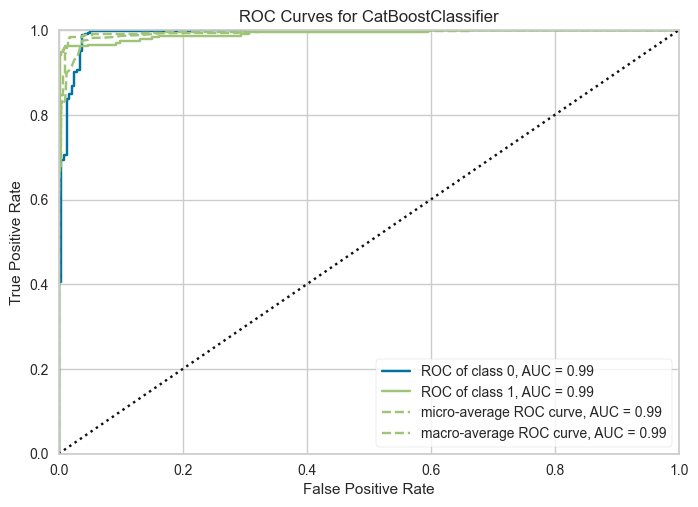

In [31]:
exp.plot_model(tuned_catboost, plot = 'auc')

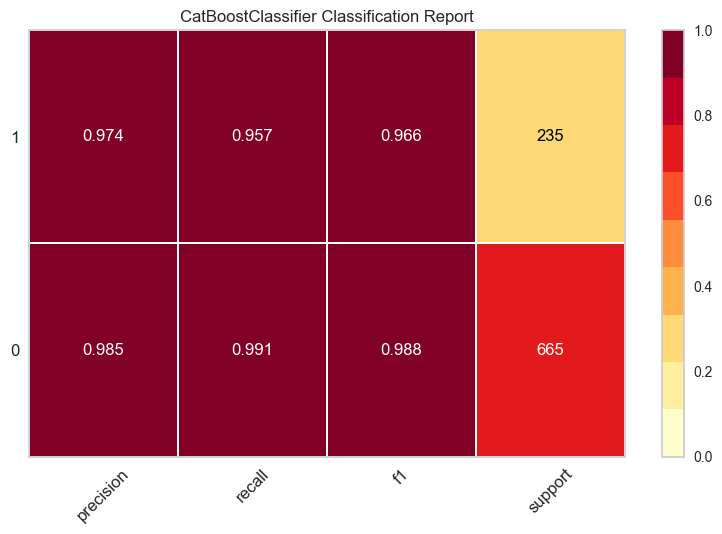

In [32]:
exp.plot_model(tuned_catboost, plot = 'class_report')

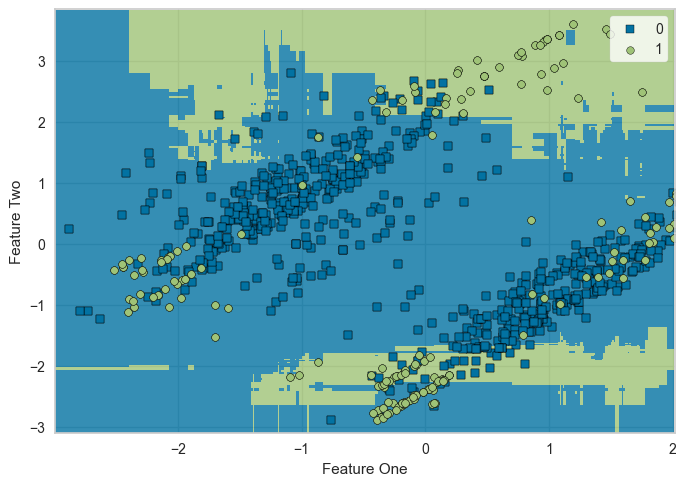

In [33]:
exp.plot_model(tuned_catboost, plot = 'boundary')

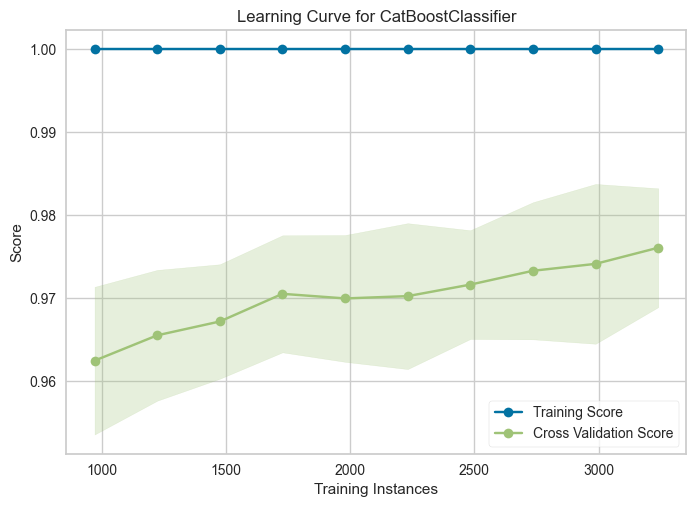

In [34]:
exp.plot_model(tuned_catboost, plot = 'learning')

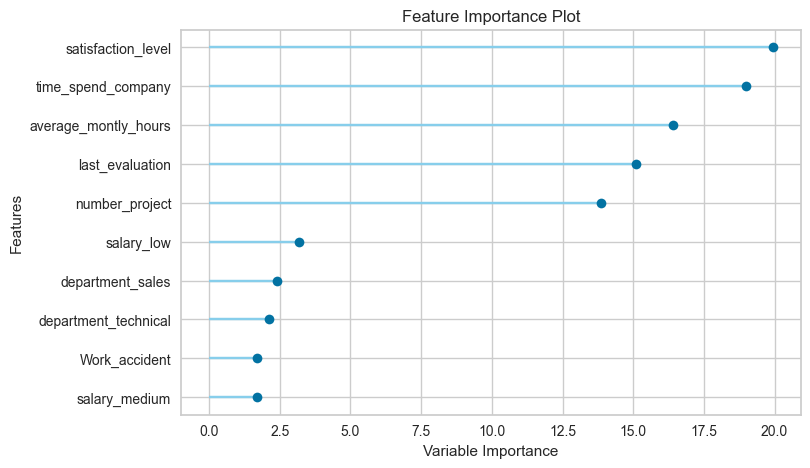

In [35]:
exp.plot_model(tuned_catboost, plot = 'feature')

## Predict Model

This function predicts Label using a trained model. When data is None, it predicts label on the holdout set. In PyCaret terminology, holdout is equivalent to our validation set.

note: so far, our best model is the tuned_catboost model with the highest CV accuracy. :)


In [36]:
holdout_pred = exp.predict_model(tuned_catboost)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,CatBoost Classifier,0.9822,0.9916,0.9574,0.9740,0.9657,0.9537,0.9537


In [37]:
holdout_pred

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,department,salary,left,prediction_label,prediction_score
3600,0.60,0.92,2,258,5,0,0,sales,low,1,0,0.9902
3601,0.65,0.95,2,180,2,0,0,product_mng,low,0,0,0.9988
3602,0.76,0.81,3,225,3,0,0,technical,medium,0,0,0.9989
3603,0.95,0.52,5,222,2,0,0,sales,low,0,0,1.0000
3604,0.11,0.88,7,305,4,0,0,product_mng,low,1,1,0.9997
...,...,...,...,...,...,...,...,...,...,...,...,...
4495,0.82,0.82,4,249,5,0,0,hr,low,1,1,0.9900
4496,0.22,0.62,6,142,3,0,0,IT,low,0,0,0.9939
4497,0.73,0.99,5,241,5,0,0,sales,low,1,1,0.9980
4498,0.57,0.55,2,173,2,0,0,RandD,low,0,0,0.9996


## Finalize Model

This function trains a given estimator on the entire dataset including the holdout set.

Model finalization is the last step in the experiment. A normal machine learning workflow in PyCaret starts with setup(), followed by comparing all models using compare_models() and shortlisting a few candidate models (based on the metric of interest) to perform several modeling techniques such as hyperparameter tuning, ensembling, stacking etc. This workflow will eventually lead you to the best model for use in making predictions on new and unseen data. The finalize_model() function fits the model onto the complete dataset including the test/hold-out sample (30% in this case). The purpose of this function is to train the model on the complete dataset before it is deployed in production.

* 5000 total observations
* 4500 used for modeling:
   - 900 is holdout set
   - 3600 is train set
* 500 unseen data

In [38]:
final_model = exp.finalize_model(tuned_catboost)

In [39]:
final_model

,steps,"[('numerical_imputer', ...), ('categorical_imputer', ...), ...]"
,memory,Memory(location=None)
,verbose,False
,transformer,SimpleImputer...rategy='mean')
,include,"['satisfaction_level', 'last_evaluation', ...]"
,exclude,None
,missing_values,nan
,strategy,'mean'
,fill_value,None
,copy,True
,add_indicator,False


### Final prediciton on unseen data

The predict_model() function is also used to predict on the unseen dataset. The only difference from section 11 above is that this time we will pass the data_unseen parameter. data_unseen is the variable created at the beginning of the tutorial and contains 10% of the original dataset which was never exposed to PyCaret.

In [40]:
unseen_predictions = exp.predict_model(final_model, data=data_unseen)
unseen_predictions

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,CatBoost Classifier,0.9840,0.9970,0.9640,0.9640,0.9640,0.9537,0.9537


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,department,salary,left,prediction_label,prediction_score
0,0.70,0.60,5,208,3,0,0,management,medium,0,0,1.0000
1,0.51,0.52,5,261,3,1,0,RandD,low,0,0,0.9999
2,0.26,0.69,4,180,3,1,0,accounting,low,0,0,0.9970
3,0.96,0.37,2,159,6,0,0,RandD,low,0,0,0.9985
4,0.17,0.89,5,261,5,0,0,marketing,medium,0,0,0.9911
...,...,...,...,...,...,...,...,...,...,...,...,...
495,0.19,0.86,4,198,6,0,0,accounting,medium,0,0,1.0000
496,0.81,0.93,5,270,5,0,0,technical,medium,1,1,0.9994
497,0.95,0.54,4,235,4,0,0,sales,medium,0,0,1.0000
498,0.49,0.77,3,147,3,0,0,support,low,0,0,0.9975


## Save Model

This function saves the transformation pipeline and trained model object into the current working directory as a pickle file for later use.

In [41]:
exp.save_model(final_model, 'my_pycaret_classifier')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['satisfaction_level',
                                              'last_evaluation',
                                              'number_project',
                                              'average_montly_hours',
                                              'time_spend_company'],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               copy=True,
                                                               fill_value=None,
                                                               keep_empty_features=False,
                                                               missing_values=nan,
                                                               strategy='mean'))),
                 ('cate...
             

## Load model

This function loads a previously saved pipeline.



In [42]:
my_winning_classifier = load_model('my_pycaret_classifier')

Transformation Pipeline and Model Successfully Loaded


In [43]:
my_winning_classifier

,steps,"[('numerical_imputer', ...), ('categorical_imputer', ...), ...]"
,memory,Memory(location=None)
,verbose,False
,transformer,SimpleImputer...rategy='mean')
,include,"['satisfaction_level', 'last_evaluation', ...]"
,exclude,None
,missing_values,nan
,strategy,'mean'
,fill_value,None
,copy,True
,add_indicator,False


Additional Links:

1. https://py-caret.readthedocs.io/en/latest/api/classification.html (PyCaret quickstart: classification)
2. https://py-caret.readthedocs.io/en/latest/api/classification.html (PyCaret classification API reference)
3. https://pypi.org/project/pycaret-core/3.5.0/ (pycaret-core 3.5.0 on PyPI, the package we install in this notebook)
4. https://github.com/sktime/pycaret/releases (PyCaret release notes)
